# ESA Mission 2: dataset analysis

## What the dataset contains

Real satellite telemetry from three ESA missions, annotated by spacecraft operations
engineers and cross-checked by ML experts, published with a benchmark meant to replace
the older spacecraft datasets whose labelling proved unreliable.

**Mission 2**: 100 channels, January 2000 to June 2003.

## Where to download it

> **Zenodo:** <https://doi.org/10.5281/zenodo.12528696> (v2: `10.5281/zenodo.15237121`)
> **Code:** <https://github.com/kplabs-pl/ESA-ADB> — **Paper:** <https://arxiv.org/abs/2406.17826>

Roughly 3.8 GB per mission, CC BY 3.0 IGO.

## What the raw data is not

**It is not a table.** Each channel is a separate pickled series on its own irregular
index: one reports 7.4 million times, another 1,703.

**The labels are not a column.** `labels.csv` gives intervals covering a stretch of
time *on a particular channel*; `anomaly_types.csv` says whether each is an `Anomaly`
or a `Rare Event`.

The table below comes from `dencast/data/preprocess/preprocess_esa.py`: every channel
on a common 18-second grid with zero-order hold — each keeps its last reported value
until it reports a new one — and the intervals materialised as per-row labels.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import yaml

TABLE = Path("../data/interim/esa/full_esa.parquet")
META = Path("../data/raw/esa/ESA-Mission2")
DECLARED = Path("../data/raw/categorical_columns.yaml")
CATEGORICAL = yaml.safe_load(DECLARED.read_text(encoding="utf-8"))["esa"]
STRIDE = 10

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NORMAL, ANOM = C[0], "#d03b3b"
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
       "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "grid.linestyle": "-", "axes.axisbelow": True,
    "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 1.6, "figure.dpi": 110,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
})
print("pandas", pd.__version__, "| matplotlib", mpl.__version__)

pandas 3.0.6 | matplotlib 3.11.2


---
## 1. The files

One file, built once over the whole recording.

In [2]:
f = pq.ParquetFile(TABLE)
names = list(f.schema_arrow.names)
channels = [c for c in names if c.startswith("channel_")]
label_cols = [c for c in names if c.startswith("label_")]
flags = [c for c in names if c.startswith("is_")]

print(f"{TABLE.name}: {f.metadata.num_rows:,} rows x {f.metadata.num_columns} columns")
print(f"  {len(channels)} channels, {len(label_cols)} per-channel labels, "
      f"{len(flags)} global flags: {', '.join(flags)}")
print(f"  {f.metadata.num_row_groups} row groups, "
      f"{TABLE.stat().st_size / 2**30:.2f} GB on disk")

lab = pd.read_parquet(TABLE, columns=flags)
step = pd.Series(lab.index).diff().dropna()
print(f"\n  from {lab.index.min()} to {lab.index.max()}")
print(f"  {(lab.index.max() - lab.index.min()).days:,} days at a step of "
      f"{step.median().total_seconds():.0f} s, irregular intervals: "
      f"{int((step != step.median()).sum())}")

full_esa.parquet: 6,129,600 rows x 203 columns
  100 channels, 100 per-channel labels, 2 global flags: is_anomaly, is_rare_event
  16 row groups, 0.35 GB on disk

  from 2000-01-01 00:00:00 to 2003-06-30 23:59:42
  1,276 days at a step of 18 s, irregular intervals: 0


---
## 2. How the recording is ordered

In [3]:

step = np.diff(lab.index.to_numpy()).astype("timedelta64[s]").astype("int64")
print(f"from {lab.index[0]} to {lab.index[-1]}")
print(f"   {len(lab):,} rows over {(lab.index[-1] - lab.index[0]).days:,} days")
print(f"   timestamps unique: {lab.index.is_unique}   monotonic: "
      f"{lab.index.is_monotonic_increasing}")
print(f"   intervals other than {int(np.median(step))} s: {int((step != np.median(step)).sum())}")
print(f"   rows expected from the span: "
      f"{int((lab.index[-1] - lab.index[0]).total_seconds() // np.median(step)) + 1:,}")

from 2000-01-01 00:00:00 to 2003-06-30 23:59:42
   6,129,600 rows over 1,276 days
   timestamps unique: True   monotonic: True
   intervals other than 18 s: 0
   rows expected from the span: 6,129,600


**The axis is exact.** 6,129,600 rows for 6,129,600 expected from the span, not one
interval other than 18 seconds, no repeated timestamp.

---
## 3. Which variables are present

In [4]:
meta = pd.read_csv(META / "channels.csv")
meta = meta[meta["Channel"].isin(channels)].reset_index(drop=True)

print("by subsystem:")
print(meta.groupby("Subsystem").agg(
    channels=("Channel", "size"),
    target=("Target", lambda s: (s == "YES").sum()),
    categorical=("Categorical", lambda s: (s == "YES").sum()),
).to_string())
print(f"\n  scored by the benchmark (Target=YES): {(meta.Target == 'YES').sum()} of {len(meta)}")
print(f"  categorical: {(meta.Categorical == 'YES').sum()}")

by subsystem:
             channels  target  categorical
Subsystem                                 
subsystem_1        57      20            2
subsystem_2         3       3            0
subsystem_4         9       0            7
subsystem_5        19      16            1
subsystem_6        12       8            0

  scored by the benchmark (Target=YES): 47 of 100
  categorical: 10


In [5]:

parts = []
for g in range(f.metadata.num_row_groups):
    parts.append(f.read_row_group(g, columns=channels).to_pandas().iloc[::STRIDE])
V = pd.concat(parts)
del parts
print(f"subsample for the statistics below: {len(V):,} rows "
      f"(every {STRIDE}th, {STRIDE * 18} s apart)")

levels = V.nunique()

updates = (V.diff().ne(0) & V.notna()).sum() / V.notna().sum()
summary = pd.DataFrame({"levels": levels, "update rate": updates})
print()
print("distinct values per channel: min %d, median %.0f, max %s"
      % (levels.min(), levels.median(), f"{levels.max():,}"))
print("update rate   : 25%% %.5f | median %.3f | 75%% %.3f"
      % (updates.quantile(.25), updates.median(), updates.quantile(.75)))
print()
for thr, lbl in ((0.001, "under 0.1%"), (0.01, "under 1%"), (0.5, "under 50%")):
    print(f"  channels moving on {lbl} of rows: {int((updates < thr).sum())}")
print()
print("the ten most static channels:")
print(summary.nsmallest(10, "update rate").to_string())

subsample for the statistics below: 612,960 rows (every 10th, 180 s apart)

distinct values per channel: min 2, median 422, max 495,738
update rate   : 25% 0.00076 | median 0.204 | 75% 0.882

  channels moving on under 0.1% of rows: 29
  channels moving on under 1% of rows: 31
  channels moving on under 50% of rows: 63

the ten most static channels:
            levels  update rate
channel_32       2     0.000003
channel_37       2     0.000003
channel_29       3     0.000005
channel_30       3     0.000005
channel_33       3     0.000005
channel_36       3     0.000005
channel_31       4     0.000007
channel_34       4     0.000007
channel_35       4     0.000007
channel_46      12     0.000020


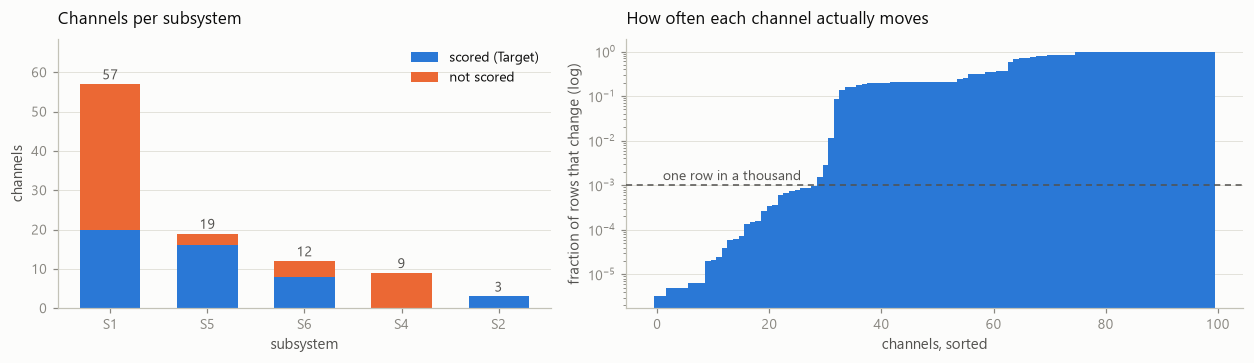

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.4), gridspec_kw={"width_ratios": [1, 1.25]})


piv = (meta.assign(scored=np.where(meta.Target == "YES", "scored", "not scored"))
           .groupby(["Subsystem", "scored"]).size().unstack(fill_value=0)
           .reindex(columns=["scored", "not scored"], fill_value=0))
piv = piv.loc[piv.sum(axis=1).sort_values(ascending=False).index]
x = np.arange(len(piv))
ax1.bar(x, piv["scored"], color=C[0], width=0.62, label="scored (Target)")
ax1.bar(x, piv["not scored"], bottom=piv["scored"], color=C[1], width=0.62, label="not scored")
for i, t in enumerate(piv.sum(axis=1)):
    ax1.text(i, t + 1.2, str(int(t)), ha="center", color=INK2, fontsize=9)
ax1.set_xticks(x, [s.replace("subsystem_", "S") for s in piv.index])
ax1.set(xlabel="subsystem", ylabel="channels", title="Channels per subsystem",
        ylim=(0, piv.sum(axis=1).max() * 1.2))
ax1.grid(axis="x", visible=False)
ax1.legend(loc="upper right")


u = np.sort(updates.to_numpy())
u = np.clip(u, 1e-6, None)
ax2.bar(range(len(u)), u, color=C[0], width=1.0)
ax2.set_yscale("log")
ax2.axhline(0.001, color=INK2, linewidth=1.0, linestyle=(0, (4, 3)), zorder=3)
ax2.text(1, 0.0013, "one row in a thousand", color=INK2, fontsize=9)
ax2.set(xlabel="channels, sorted", ylabel="fraction of rows that change (log)",
        title="How often each channel actually moves")
ax2.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

---
## 4. Data quality



### Where the table has no data

A channel that had not yet reported when the window opened has no value to hold
forward, so those rows are NaN. Nothing else produces one: the raw files have no
missing values, and once a channel starts the hold covers every row to the end.

In [7]:

nan = pd.Series(0, index=channels, dtype="int64")
for g in range(f.metadata.num_row_groups):
    nan += f.read_row_group(g, columns=channels).to_pandas().isna().sum()

N = f.metadata.num_rows
cells = N * len(channels)
print(f"NaN cells: {nan.sum():,} of {cells:,} ({nan.sum() / cells:.3%})")
print(f"  channels with at least one: {int((nan > 0).sum())} of {len(channels)}")
print(f"  channels with none        : {', '.join(nan[nan == 0].index)}")
print()
print("the six channels missing most, in rows and in time:")
for c, v in nan.sort_values(ascending=False).head(6).items():
    print(f"   {c:<12} {v:>9,} rows   {v * 18 / 3600:>9.2f} h   {v / N:7.3%} of the table")


print()
print("channels present, cumulatively:")
present = 0
for rows, k in nan.value_counts().sort_index().items():
    present += int(k)
    print(f"   from row {rows:>8,}  (+{str(pd.to_timedelta(rows * 18, unit='s')):>16})  "
          f"{present:>3} channels")

NaN cells: 563,161 of 612,960,000 (0.092%)
  channels with at least one: 99 of 100
  channels with none        : channel_100

the six channels missing most, in rows and in time:
   channel_56     279,675 rows     1398.38 h    4.563% of the table
   channel_57     279,675 rows     1398.38 h    4.563% of the table
   channel_4        3,547 rows       17.73 h    0.058% of the table
   channel_67          43 rows        0.21 h    0.001% of the table
   channel_68          43 rows        0.21 h    0.001% of the table
   channel_66          43 rows        0.21 h    0.001% of the table

channels present, cumulatively:
   from row        0  (+ 0 days 00:00:00)    1 channels
   from row        1  (+ 0 days 00:00:18)   93 channels
   from row       43  (+ 0 days 00:12:54)   97 channels
   from row    3,547  (+ 0 days 17:44:06)   98 channels
   from row  279,675  (+58 days 06:22:30)  100 channels


In [8]:

worst = nan.sort_values(ascending=False).head(6).index.tolist()
W = pd.read_parquet(TABLE, columns=worst)
for c in worst:
    m = W[c].isna().to_numpy()
    k = int(m.sum())
    prefix = bool(m[:k].all()) and not bool(m[k:].any())
    print(f"   {c:<12} {k:>9,} NaN   prefix only: {str(prefix):<5}   "
          f"first reading {W.index[k]}  (+{W.index[k] - W.index[0]})")
del W

   channel_56     279,675 NaN   prefix only: True    first reading 2000-02-28 06:22:30  (+58 days 06:22:30)
   channel_57     279,675 NaN   prefix only: True    first reading 2000-02-28 06:22:30  (+58 days 06:22:30)
   channel_4        3,547 NaN   prefix only: True    first reading 2000-01-01 17:44:06  (+0 days 17:44:06)
   channel_67          43 NaN   prefix only: True    first reading 2000-01-01 00:12:54  (+0 days 00:12:54)
   channel_68          43 NaN   prefix only: True    first reading 2000-01-01 00:12:54  (+0 days 00:12:54)
   channel_66          43 NaN   prefix only: True    first reading 2000-01-01 00:12:54  (+0 days 00:12:54)


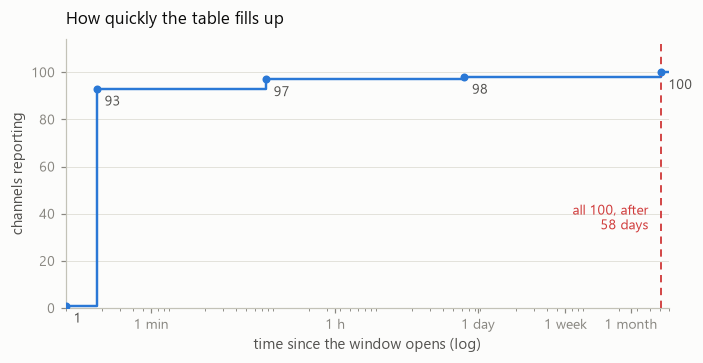

In [9]:
ladder = nan.value_counts().sort_index()
secs = np.clip(ladder.index.to_numpy() * 18, 9, None)   # row 0 has no elapsed time
cum = ladder.to_numpy().cumsum()
END = 70 * 86400

fig, ax = plt.subplots(figsize=(6.5, 3.4))

ax.step(np.r_[secs, END], np.r_[cum, cum[-1]], where="post", color=C[0])
ax.scatter(secs, cum, s=18, color=C[0], zorder=4)
ax.set_xscale("log")

for x, y in zip(secs, cum):
    ax.annotate(f"{y}", xy=(x, y), xytext=(5, -11), textcoords="offset points",
                color=INK2, fontsize=9)

ax.axvline(secs[-1], color=ANOM, linewidth=1.2, linestyle=(0, (4, 3)), zorder=3)
ax.annotate("all 100, after\n58 days", xy=(secs[-1], 38), xytext=(-8, 0),
            textcoords="offset points", ha="right", va="center",
            color=ANOM, fontsize=9)

ax.set_xlim(9, END)
ax.set_ylim(0, 114)
ax.set_xticks([60, 3600, 86400, 7 * 86400, 30 * 86400],
              ["1 min", "1 h", "1 day", "1 week", "1 month"])
ax.set(xlabel="time since the window opens (log)", ylabel="channels reporting",
       title="How quickly the table fills up")
ax.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

---
## 5. The anomalies

644 events are annotated, and the distinction between them is the first thing to look
at: **613 are `Rare Event`, not `Anomaly`** — unusual but legitimate behaviours,
annotated precisely so they would not be counted as faults. The per-channel label is
ternary (0 nominal, 1 anomaly, 2 rare event).

In [10]:
kinds = pd.read_csv(META / "anomaly_types.csv")
print("the 644 annotations, by category and shape:")
for col in ("Category", "Dimensionality", "Locality", "Length"):
    print(f"  {col:<16} {kinds[col].value_counts().to_dict()}")

def segments(y: np.ndarray):
    ch = np.diff(np.r_[0, (y != 0).astype(int), 0])
    return np.flatnonzero(ch == 1), np.flatnonzero(ch == -1)

a = lab["is_anomaly"].to_numpy()
r = lab["is_rare_event"].to_numpy()
s, e = segments(a)
dur_h = (e - s) * 18 / 3600
print()
print(f"anomaly rows    : {int(a.sum()):,} ({a.mean():.3%}) in {len(s)} segments")
print(f"rare event rows : {int(r.sum()):,} ({r.mean():.3%})")
print(f"segment length (hours): min {dur_h.min():.2f} | median {np.median(dur_h):.2f} "
      f"| max {dur_h.max():.1f}")
print()
# The count is the check that the preprocessing lost nothing: the dataset declares
# 31 Anomaly events over the whole recording, and the table contains 31 runs.
print(f"declared Anomaly events: {int((kinds.Category == 'Anomaly').sum())}   "
      f"segments in the table: {len(s)}")
print()
print("segment starts by year:",
      pd.Series(lab.index[s]).dt.year.value_counts().sort_index().to_dict())

the 644 annotations, by category and shape:
  Category         {'Rare Event': 613, 'Anomaly': 31}
  Dimensionality   {'Multivariate': 635, 'Univariate': 9}
  Locality         {'Global': 585, 'Local': 59}
  Length           {'Subsequence': 644}

anomaly rows    : 106,143 (1.732%) in 31 segments
rare event rows : 235,320 (3.839%)
segment length (hours): min 0.13 | median 1.25 | max 465.2

declared Anomaly events: 31   segments in the table: 31

segment starts by year: {2000: 21, 2001: 5, 2002: 4, 2003: 1}


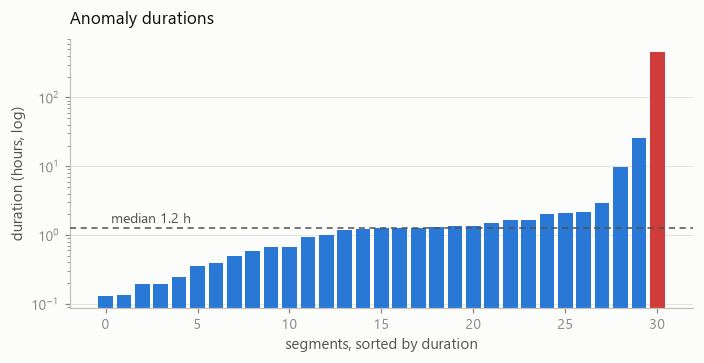

the longest segment lasts 465.2 hours (19.4 days) and alone covers 88% of all anomalous rows


In [11]:

order = np.sort(dur_h)

fig, ax = plt.subplots(figsize=(6.5, 3.4))

ax.bar(range(len(order)), order, color=C[0], width=0.8)
ax.bar([len(order) - 1], [order[-1]], color=ANOM, width=0.8)
ax.set_yscale("log")
ax.axhline(np.median(dur_h), color=INK2, linewidth=1.0, linestyle=(0, (4, 3)), zorder=3)
ax.text(0.3, np.median(dur_h) * 1.2, f"median {np.median(dur_h):.1f} h",
        color=INK2, fontsize=9)
ax.set(xlabel="segments, sorted by duration", ylabel="duration (hours, log)",
       title="Anomaly durations")
ax.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

share = (e - s).max() / (e - s).sum()
print(f"the longest segment lasts {dur_h.max():.1f} hours ({dur_h.max()/24:.1f} days) "
      f"and alone covers {share:.0%} of all anomalous rows")

**One event dominates everything measured per row.** The longest anomaly runs for
weeks and holds the overwhelming majority of anomalous rows.

C:\Users\bevia\AppData\Local\Temp\ipykernel_34204\2628429396.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


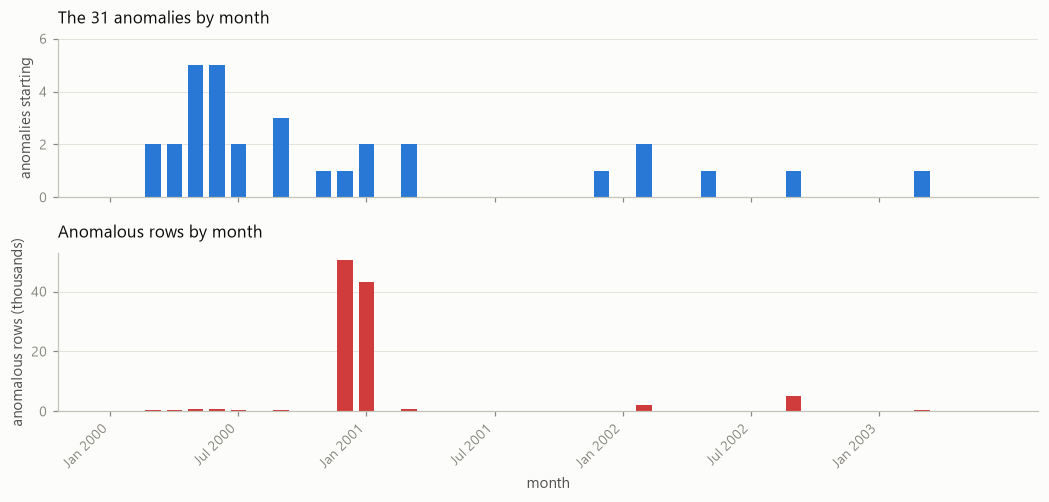

         anomalies  anomalous rows share of rows
2000-03          2             438          0.4%
2000-04          2             569          0.5%
2000-05          5             821          0.8%
2000-06          5             890          0.8%
2000-07          2             337          0.3%
2000-09          3             618          0.6%
2000-11          1              26          0.0%
2000-12          1           50398         47.5%
2001-01          2           43142         40.6%
2001-03          2             650          0.6%
2001-12          1             269          0.3%
2002-02          2            2308          2.2%
2002-05          1             252          0.2%
2002-09          1            5089          4.8%
2003-03          1             336          0.3%

15 of the 42 months contain an anomaly; the busiest holds 5 of 31
the heaviest month, 2000-12, holds 47% of all anomalous rows; the busiest in events is 2000-05, a different month


In [12]:

t = lab.index
starts = pd.Series(t[s]).dt.to_period("M")
mass = pd.Series(t[a.astype(bool)]).dt.to_period("M")
span = pd.period_range(t[0].to_period("M"), t[-1].to_period("M"), freq="M")
count = starts.value_counts().reindex(span, fill_value=0)
rows_m = mass.value_counts().reindex(span, fill_value=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 4.4), sharex=True,
                               gridspec_kw={"hspace": 0.35})
x = np.arange(len(span))
ax1.bar(x, count.to_numpy(), color=C[0], width=0.72)
ax1.set(ylabel="anomalies starting", title=f"The {len(s)} anomalies by month",
        ylim=(0, max(count.max() * 1.2, 1)))
ax1.grid(axis="x", visible=False)
ax2.bar(x, rows_m.to_numpy() / 1000, color=ANOM, width=0.72)
ax2.set(ylabel="anomalous rows (thousands)", xlabel="month",
        title="Anomalous rows by month")
ax2.grid(axis="x", visible=False)
ticks = [i for i, p in enumerate(span) if p.month in (1, 7)]
ax2.set_xticks(ticks, [span[i].strftime("%b %Y") for i in ticks],
               rotation=45, ha="right")
fig.tight_layout()
plt.show()

table = pd.DataFrame({"anomalies": count, "anomalous rows": rows_m})
table = table[table.sum(axis=1) > 0]
table["share of rows"] = (table["anomalous rows"] / rows_m.sum()).map("{:.1%}".format)
print(table.to_string())
print()
print(f"{int((count > 0).sum())} of the {len(span)} months contain an anomaly; "
      f"the busiest holds {count.max()} of {len(s)}")
same = count.idxmax() == rows_m.idxmax()
print(f"the heaviest month, {rows_m.idxmax()}, holds {rows_m.max() / rows_m.sum():.0%} "
      f"of all anomalous rows; the busiest in events is {count.idxmax()}"
      f"{', the same month' if same else ', a different month'}")

**The months with the most anomalies are not the months with the most anomalous
rows.**

Only 15 of the 42 months contain an anomaly; the other 27 are nominal end to end.

---
## 6. Descriptive statistics


### The continuous channels

In [ ]:

flags = []
for g in range(f.metadata.num_row_groups):
    blk = f.read_row_group(g, columns=["is_anomaly", "is_rare_event"]).to_pandas()
    blk = blk.iloc[::STRIDE]
    flags.append(((blk["is_anomaly"] == 0) & (blk["is_rare_event"] == 0)).to_numpy())
nominal = np.concatenate(flags)
assert len(nominal) == len(V)
cat_ch = [c for c in channels if c in set(CATEGORICAL)]
con_ch = [c for c in channels if c not in set(CATEGORICAL)]

print(f"nominal rows in the subsample: {int(nominal.sum()):,} of {len(V):,} "
      f"({nominal.mean():.2%})")
print(f"   {len(con_ch)} numeric channels, {len(cat_ch)} categorical "
      f"(as categorical_columns.yaml declares them, not by cardinality)")

desc = V.loc[nominal, con_ch].describe().T
desc[["count", "mean", "std", "min", "50%", "max"]].round(3)

nominal rows in the subsample: 578,925 of 612,960 (94.45%)
   90 continuous channels, 10 categorical (as categorical_columns.yaml declares them, not by cardinality)


,count,mean,std,min,50%,max
channel_1,578924.0,0.569,0.277,0.001,0.631,0.999
channel_2,578924.0,0.499,0.001,0.281,0.499,0.501
channel_3,578924.0,0.500,0.000,0.498,0.500,0.624
channel_6,578924.0,1.000,0.000,1.000,1.000,1.000
channel_7,578924.0,0.010,0.000,0.004,0.010,0.018
...,...,...,...,...,...,...
channel_96,578924.0,0.410,0.271,0.000,0.357,1.000
channel_97,578924.0,0.499,0.283,0.000,0.501,1.000
channel_98,578924.0,0.503,0.301,0.000,0.456,1.000
channel_99,578924.0,0.906,0.142,0.000,1.000,1.000


### The categorical channels


In [14]:

K = pd.read_parquet(TABLE, columns=cat_ch)
keep = ((lab["is_anomaly"] == 0) & (lab["is_rare_event"] == 0)).to_numpy()
K = K.loc[keep]

rows = []
for c in cat_ch:
    col = K[c].dropna()
    vc = col.value_counts(normalize=True)
    rows.append({"channel": c, "levels": int(col.nunique()),
                 "dominant state": float(vc.index[0]),
                 "dominant share": round(float(vc.iloc[0]), 4),
                 "transitions": int((col.diff() != 0).sum() - 1)})
states = pd.DataFrame(rows).sort_values("transitions", ascending=False)
print(states.to_string(index=False))
print()
still = states.loc[states["transitions"] == 0, "channel"].tolist()
print(f"categorical channels that never change state in nominal operation: "
      f"{len(still)} of {len(cat_ch)}")
if still:
    print("   " + ", ".join(still))

   channel  levels  dominant state  dominant share  transitions
 channel_5       2             0.0          0.9998          168
channel_47       4             0.0          0.9915           57
 channel_4       2             0.0          0.9660           54
channel_53       3             0.0          0.6479           37
channel_51       3             0.0          0.6045           31
channel_50       3             0.0          0.6338           30
channel_52       3             0.0          0.8801           16
channel_54       3             2.0          0.7370           12
channel_55       3             1.0          0.7370            8
channel_60       1             0.0          1.0000            0

categorical channels that never change state in nominal operation: 1 of 10
   channel_60


### Pearson, on the continuous channels

continuous channels with variance in nominal operation: 86 of 90
  dropped as constant: channel_25, channel_26, channel_27, channel_28


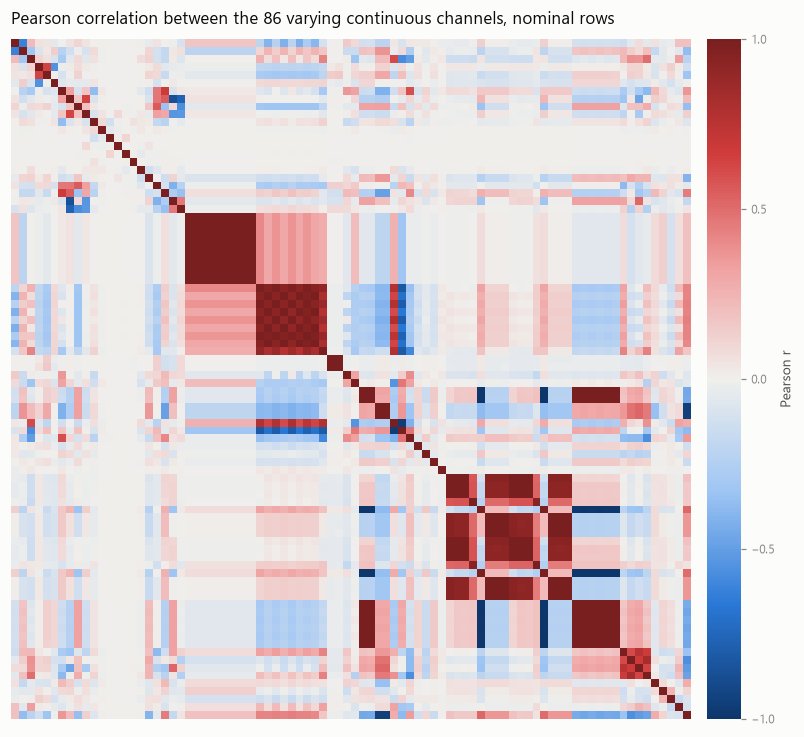

3,655 distinct pairs   median |r| = 0.067   |r| > 0.8: 5.2%   |r| > 0.5: 7.0%

most strongly correlated pairs:
   channel_30   ~ channel_36   r = +1.0000   same subsystem
   channel_30   ~ channel_34   r = +1.0000   same subsystem
   channel_30   ~ channel_32   r = +1.0000   same subsystem
   channel_30   ~ channel_31   r = +1.0000   same subsystem
   channel_37   ~ channel_34   r = +1.0000   same subsystem
   channel_37   ~ channel_35   r = +1.0000   same subsystem
   channel_31   ~ channel_33   r = +1.0000   same subsystem
   channel_37   ~ channel_36   r = +1.0000   same subsystem
   channel_37   ~ channel_30   r = +1.0000   same subsystem
   channel_31   ~ channel_36   r = +1.0000   same subsystem


In [ ]:
sd = V.loc[nominal, con_ch].std()
numeric = [c for c in con_ch if sd[c] > 1e-9]
dropped = [c for c in con_ch if sd[c] <= 1e-9]
print(f"numeric channels with variance in nominal operation: {len(numeric)} "
      f"of {len(con_ch)}")
if dropped:
    print("  dropped as constant:", ", ".join(dropped))

corr = V.loc[nominal, numeric].corr()          # method="pearson" is the default

fig, ax = plt.subplots(figsize=(8.0, 6.8))
div = mpl.colors.LinearSegmentedColormap.from_list(
    "div", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#f0a0a0", "#d03b3b", "#7a1f1f"])
im = ax.imshow(corr.values, cmap=div, vmin=-1, vmax=1, aspect="equal")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Pearson correlation between the {len(numeric)} varying numeric "
             f"channels, nominal rows")
ax.grid(visible=False)
for sp in ax.spines.values():
    sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, ticks=[-1, -0.5, 0, 0.5, 1])
cb.set_label("Pearson r", color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

vals = np.abs(corr.values[np.triu_indices(len(corr), 1)])
print(f"{len(vals):,} distinct pairs   median |r| = {np.median(vals):.3f}   "
      f"|r| > 0.8: {(vals > 0.8).mean():.1%}   |r| > 0.5: {(vals > 0.5).mean():.1%}")

off = corr.where(~np.eye(len(corr), dtype=bool)).stack().sort_values(key=abs, ascending=False)
seen, top = set(), []
for (i, j), v in off.items():
    if (j, i) in seen:
        continue
    seen.add((i, j)); top.append((i, j, float(v)))
    if len(top) == 10:
        break
sub = dict(zip(meta.Channel, meta.Subsystem))
print("\nmost strongly correlated pairs:")
for i, j, v in top:
    same = "same subsystem" if sub.get(i) == sub.get(j) else "across subsystems"
    print(f"   {i:<12} ~ {j:<12} r = {v:+.4f}   {same}")

### Cramer's V, on the categorical channels

categorical channels: 10   varying in nominal operation: 9
Cramer's V computed over 9 columns (36 pairs), n = 5,789,175 rows


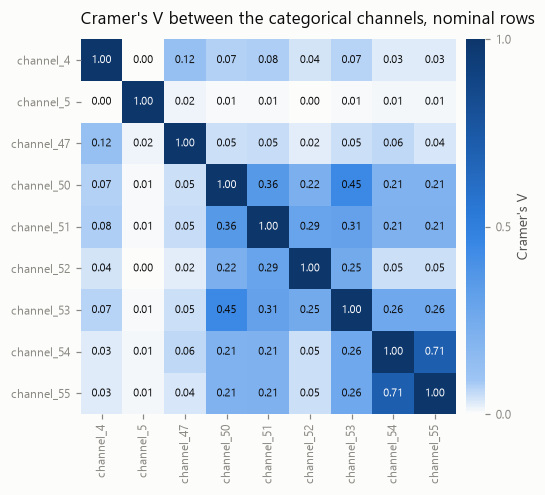

most strongly associated pairs in nominal operation:
   channel_55   ~ channel_54   V = 0.707
   channel_53   ~ channel_50   V = 0.448
   channel_50   ~ channel_51   V = 0.358
   channel_51   ~ channel_53   V = 0.308
   channel_51   ~ channel_52   V = 0.290
   channel_55   ~ channel_53   V = 0.263
   channel_53   ~ channel_54   V = 0.263
   channel_52   ~ channel_53   V = 0.252

36 distinct pairs   median V = 0.056   V > 0.8: 0.0%   V > 0.5: 2.8%


In [16]:
from scipy.stats import chi2_contingency

cram_cols = [c for c in cat_ch if K[c].nunique() > 1]
n_nom = len(K)
cram = pd.DataFrame(np.eye(len(cram_cols)), index=cram_cols, columns=cram_cols)
for i, a_ in enumerate(cram_cols):
    for b_ in cram_cols[i + 1:]:
        table_ = pd.crosstab(K[a_], K[b_])
        stat = chi2_contingency(table_)[0]
        v = float(np.sqrt(stat / (n_nom * (min(table_.shape) - 1))))
        cram.loc[a_, b_] = cram.loc[b_, a_] = v

print(f"categorical channels: {len(cat_ch)}   varying in nominal operation: "
      f"{len(cram_cols)}")
print(f"Cramer's V computed over {len(cram_cols)} columns "
      f"({len(cram_cols) * (len(cram_cols) - 1) // 2} pairs), n = {n_nom:,} rows")

fig, ax = plt.subplots(figsize=(5.6, 4.6))
seq = mpl.colors.LinearSegmentedColormap.from_list("seq", ["#fcfcfb"] + SEQ[2:])
im = ax.imshow(cram.values, cmap=seq, vmin=0, vmax=1, aspect="equal")
ax.set_xticks(range(len(cram_cols)), cram_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(cram_cols)), cram_cols, fontsize=8)
for i in range(len(cram_cols)):
    for j in range(len(cram_cols)):
        v = cram.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="#ffffff" if v > 0.6 else INK)
ax.set_title("Cramer's V between the categorical channels, nominal rows")
ax.grid(visible=False)
for sp in ax.spines.values():
    sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, ticks=[0, 0.5, 1])
cb.set_label("Cramer's V", color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

off = cram.where(~np.eye(len(cram), dtype=bool)).stack().sort_values(ascending=False)
seen, top_v = set(), []
for (i, j), v in off.items():
    if (j, i) in seen:
        continue
    seen.add((i, j))
    top_v.append((i, j, float(v)))
    if len(top_v) == 8:
        break
print("most strongly associated pairs in nominal operation:")
for i, j, v in top_v:
    print(f"   {i:<12} ~ {j:<12} V = {v:.3f}")
flat = cram.to_numpy()[np.triu_indices(len(cram), 1)]
print()
print(f"{len(flat)} distinct pairs   median V = {np.median(flat):.3f}   "
      f"V > 0.8: {(flat > 0.8).mean():.1%}   V > 0.5: {(flat > 0.5).mean():.1%}")
del K

---
## 7. Summary

**The dataset.** 100 channels of expert-annotated satellite telemetry over three and a
half years, delivered as per-channel series on irregular indices and reassembled here
onto one 18-second grid with zero-order hold.

**What has to be handled.**

| issue | detail |
|---|---|
| no table in the raw data | 100 channels on independent irregular indices |
| the first 58 days are incomplete | two channels start on 28 February 2000; their lead-in is left NaN, not imputed |
| labels are intervals, not a column | `(ID, Channel, StartTime, EndTime)` plus a category, materialised per row |
| 613 of 644 annotations are not anomalies | `Rare Event` is unusual but nominal; counting it as a positive changes the task |
| a third of the channels are near-constant | 29 change on under one row in a thousand while reporting at full rate: discrete states, not slow signals |

**What makes it tractable.**

- The annotation is **per channel**: attribution becomes measurable.
- Annotations are overwhelmingly **multivariate**.
- The recording is **continuous and long**.